In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Data Collection

In [2]:
df = pd.read_csv("loan.csv")
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [3]:
# Before Encoding
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [4]:
df.describe()
# give info ONLY about Numerical columns

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.shape
# gives (no. of rows, no. of cols)

(614, 13)

In [6]:
df.size
# no. of rows * no. of cols = total no. of elements present

7982

# Data Cleaning

In [7]:
print(df.duplicated().sum())

0


In [8]:
df.drop("Loan_ID", axis=1, inplace=True)
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [9]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['ApplicantIncome','CoapplicantIncome'], axis=1, inplace=True)

In [10]:
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,NaN,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0


# Handling Missing Values

In [11]:
df.isnull().sum()

Gender              13
Married              3
Dependents          15
Education            0
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
Property_Area        0
Loan_Status          0
Total_Income         0
dtype: int64

In [12]:
# Filling all the Categorical columns with their Mode
for col in df.select_dtypes(include=['object']).columns:
    most_freq = df[col].mode()[0]
    df[col] = df[col].fillna(most_freq)
    df[col] = df[col].fillna(most_freq)

C:\Users\user\AppData\Local\Temp\ipykernel_4332\726615801.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [13]:
# Filling all the Numerical columns with their Mode
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [14]:
df.isnull().sum()

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Loan_Status         0
Total_Income        0
dtype: int64

# Handling Outliers

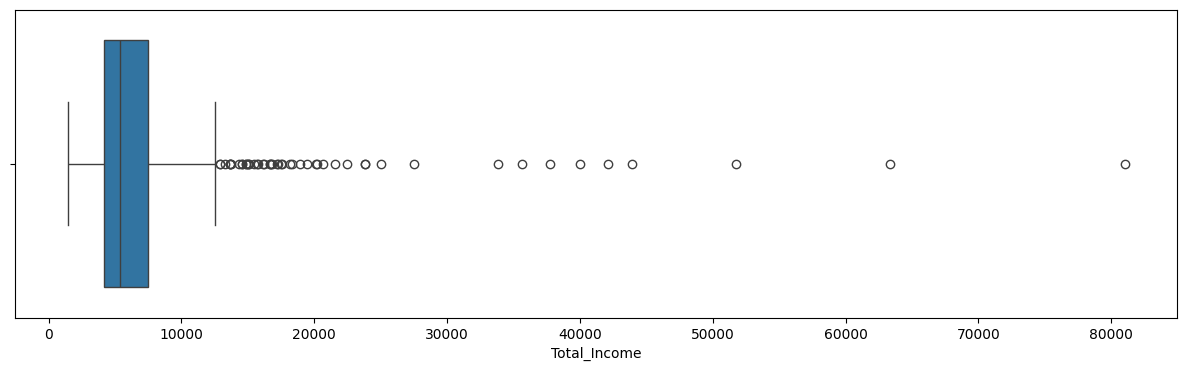

In [15]:
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'Total_Income', data = df)
plt.show()

### Outlier Removal Using IQR Method

In [16]:
q1 = df["Total_Income"].quantile(0.25)
q3 = df["Total_Income"].quantile(0.75)
IQR = q3 - q1
IQR

np.float64(3355.75)

In [17]:
min_range = q1 - (1.5*IQR)
max_range = q3 + (1.5*IQR)
min_range, max_range

(np.float64(-867.625), np.float64(12555.375))

### Removing outliers from original data set

In [18]:
# We will accept those data which have less income than 'max_range' income
df = df[(df["Total_Income"] >= min_range) & (df["Total_Income"] <= max_range)]
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0


In [19]:
df.shape # 564 rows

(564, 11)

In [20]:
# 614 - 564 = 50 rows removed

### After Handling outliers using IQR

C:\Users\user\AppData\Local\Temp\ipykernel_4332\4037175871.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Total_Income"])


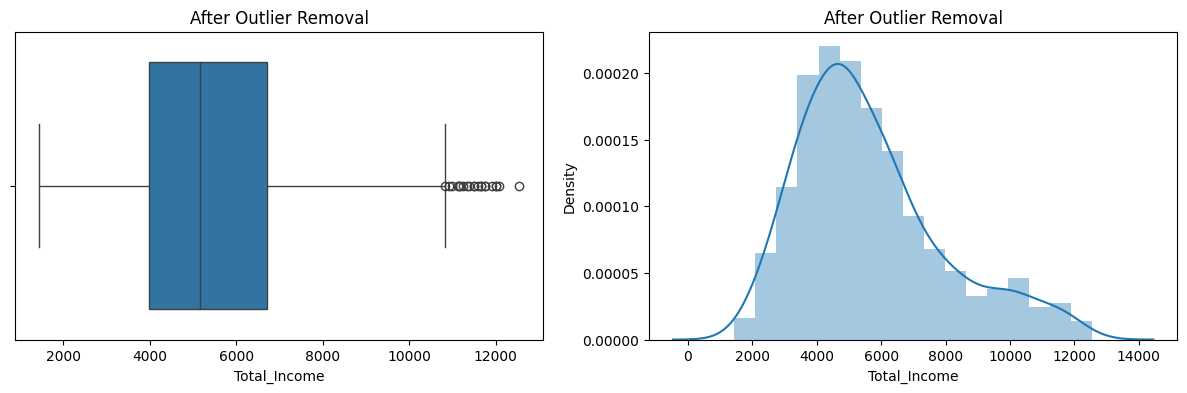

In [21]:
plt.figure(figsize=(15, 4))

# Checking outliers through boxplot
plt.subplot(1,2,1)
plt.title("After Outlier Removal")
sns.boxplot(x = 'Total_Income', data = df)

# Before Outlier Removal for 'x_train'
plt.subplot(1,2,2) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("After Outlier Removal")
sns.distplot(df["Total_Income"])

plt.show()

# * CATEGORICAL ENCODING
Converting categorical data to Numeric data, coz ML models work on Mathematical formulae & can be applied to nos. only

In [22]:
# Converting categorical to Numerical format: 
# in Ml - columns are variables - (numerical(continuous, discrete), categorical(ordinal, nominal))
# ordinal define order, nominal do not define order
# ordinal encoding and label encoding: to convert ordinal categorical into numerical
# nominal categorical variable we use- one hot encoder or dummy variable

Ordinal categorical data → Ordinal Encoding (E.g. here, Dependents --> (0, 1, 2, 3+))

Nominal categorical feature → One-Hot Encoding (E.g. here, "Gender", "Married", "Education", "Self_Employed", "Property_Area")

NOTE: "Property_Area" creates too many columns when using 'OneHotEncoder', so we may apply 'LabelEncoder' for "Property_Area" if using tree-based models like RandomForest, DecisionTree, etc., coz because 'LabelEncoder' creates ORDER, so trees split categories differently and are less affected by numeric order. 
But do not use 'LabelEncoder' for models like Logistic Regression, K-Nearest Neighbors, Support Vector Machine.
Since, here we are testing which model fits the best, so all kinds of models are used, so here better to apply 'OneHotEncoder' for 

Target variable → Label Encoding often used (E.g. here, Loan_Status)

So at the time of TESTING THE MODELS, use:

Ordinal categorical data → Ordinal Encoding

Nominal categorical feature → One-Hot Encoding

Target variable → Label Encoding often used 

## i) One-Hot Encoder

In [23]:
df1 = df[["Gender", "Married", "Education", "Self_Employed", "Property_Area"]]
df1.head(2)

,Gender,Married,Education,Self_Employed,Property_Area
0,Male,No,Graduate,No,Urban
1,Male,Yes,Graduate,No,Rural


In [24]:
df_dummy = pd.get_dummies(df1)

In [25]:
df_dummy.head(2)

,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,False,True,True,False,True,False,True,False,False,False,True
1,False,True,False,True,True,False,True,False,True,False,False


In [26]:
df_dummy = df_dummy.astype(int)
df_dummy.head(2)

,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,1,1,0,1,0,1,0,0,0,1
1,0,1,0,1,1,0,1,0,1,0,0


In [27]:
df_dummy.columns

Index(['Gender_Female', 'Gender_Male', 'Married_No', 'Married_Yes',
       'Education_Graduate', 'Education_Not Graduate', 'Self_Employed_No',
       'Self_Employed_Yes', 'Property_Area_Rural', 'Property_Area_Semiurban',
       'Property_Area_Urban'],
      dtype='str')

Sparse matrix is the matrix in which most of the contents are filled with 0s and 1s

Here the dataframe becomes too large, so to avoid redundancy, we can use 'drop = "first" '

In [28]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first") # USING DUMMY ENCODING, drop="first" --> Drops the first variable of one type without affecting the rest
enc_arr = ohe.fit_transform(df1).toarray() # 'fit_transform', fit --> understands the data, transform --> converts data from categorical to numerical 
enc_arr

array([[1., 0., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 0.],
       [1., 1., 0., 1., 0., 1.],
       ...,
       [1., 1., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 1.],
       [0., 0., 0., 1., 1., 0.]], shape=(564, 6))

#### NOTE: At the time of DEPLOYMENT, we do 'fit' & 'transform' separately 

In [29]:
enc_df = pd.DataFrame(enc_arr, columns=['Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 
                                        'Property_Area_Semiurban', 'Property_Area_Urban'])

enc_df.head(2)

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0


In [30]:
# df[['Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']] = enc_df[['Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']]
# df

## ii) Label Encoder

In [31]:
# Before transform --> 'Loan_Status'
# CREATED ANOTHER DATAFRAME TO CHECK WHAT VALUE IS ENCODED TO WHAT IN NUMERIC FORMAT
df_enc_analysis = pd.DataFrame(df['Loan_Status']) # creating 'df['Loan_Status']' as dataframe, as just assigning a single column will make it as Series dataset
df_enc_analysis.head(3)

,Loan_Status
0,Y
1,N
2,Y


In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['Loan_Status'])

LabelEncoder()

In [33]:
df['Loan_Status'] = le.transform(df['Loan_Status'])

In [34]:
# CREATING ANOTHER COLUMN AND ATTACHING IT TO THE NEWLY CREATED DATAFRAME 'df_enc_analysis'
df_enc_analysis['Loan_Status_enc'] = df['Loan_Status'] # here, 'df['Loan_Status']' gets encoded to NUMERIC FORMAT
df_enc_analysis.head(3)

,Loan_Status,Loan_Status_enc
0,Y,1
1,N,0
2,Y,1


In [35]:
df_enc_analysis['Loan_Status'].unique() 
# gives unique values which is set by LabelEncoder()

<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str

In [36]:
df_enc_analysis['Loan_Status_enc'].unique() 

array([1, 0])

## iii) Ordinal Encoding (using Sklearn)

In [37]:
# Before transform --> 'Dependents'
# CREATED ANOTHER DATAFRAME TO CHECK WHAT VALUE IS ENCODED TO WHAT IN NUMERIC FORMAT
df_enc_analysis2 = pd.DataFrame(df['Dependents']) # creating 'df['Loan_Status']' as dataframe, as just assigning a single column will make it as Series dataset
df_enc_analysis2.head(10)

,Dependents
0,0
1,1
2,0
3,0
4,0
5,2
6,0
7,3+
8,2
10,2


In [38]:
from sklearn.preprocessing import OrdinalEncoder

ord_data = [["0", "1", "2", "3+"]] # here we 2 square brackets, coz here 2-D array is needed

oe = OrdinalEncoder(categories=ord_data) # categories=ord_data, is done to keep the data for the given column ORDER-WISE, else the order will be distrurbed as OrdinalEncoder arranges it ALPHABETICAL-WISE
oe.fit(df[["Dependents"]])


,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['0', '1', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [39]:
df["Dependents"]  = oe.transform(df[["Dependents"]])

In [40]:
# CREATING ANOTHER COLUMN AND ATTACHING IT TO THE NEWLY CREATED DATAFRAME 'df_enc_analysis'
df_enc_analysis2['Dependents_enc'] = df['Dependents'] # here, 'df['Loan_Status']' gets encoded to NUMERIC FORMAT
df_enc_analysis2.head(10)

,Dependents,Dependents_enc
0,0,0.0
1,1,1.0
2,0,0.0
3,0,0.0
4,0,0.0
5,2,2.0
6,0,0.0
7,3+,3.0
8,2,2.0
10,2,2.0


## iii) Ordinal Encoding (using map() func. )

In [41]:
# Here we use the dictionary, and can give encoded nos. as per our choice in the form of "values"
ord_data2 = {"0":0, "1":1, "2":2, "3+":3}
df_enc_analysis2['Dependents_enc_map'] = df['Dependents'].map(ord_data2) # here, 'df['Loan_Status']' gets encoded to NUMERIC FORMAT
df_enc_analysis2.head(2)

,Dependents,Dependents_enc,Dependents_enc_map
0,0,0.0,NaN
1,1,1.0,NaN


In [42]:
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0.0,Graduate,No,128.0,360.0,1.0,Urban,1,5849.0
1,Male,Yes,1.0,Graduate,No,128.0,360.0,1.0,Rural,0,6091.0


In [43]:
df = pd.concat(
    [df.drop(columns = df1.columns), enc_df],
    axis=1
)

In [44]:
df.head(2)

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.0,128.0,360.0,1.0,1.0,5849.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,128.0,360.0,1.0,0.0,6091.0,1.0,1.0,0.0,0.0,0.0,0.0
